<a href="https://colab.research.google.com/github/Arishiine/Machine-Learning-Notes/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

Logistic Regression is a statistical model primarily used for binary classification tasks. Despite its name, it's a classification algorithm, not a regression algorithm in the traditional sense, as it predicts the probability of an outcome, which is then mapped to a class (e.g., 0 or 1).

## 1. Simple Dataset Creation

   Study_Hours  Exam_Score  Passed
0     5.993428   55.846293       1
1     4.723471   65.793547       1
2     6.295377   66.572855       1
3     8.046060   61.977227       1
4     4.531693   68.387143       0
Passed
1    83
0    17
Name: count, dtype: int64


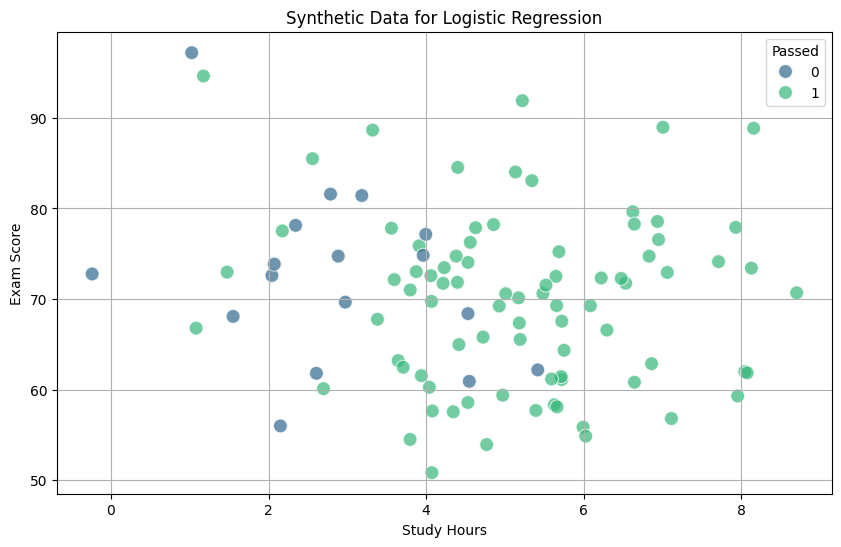

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_samples = 100

# Feature 1 (e.g., Study Hours)
X1 = np.random.normal(loc=5, scale=2, size=num_samples)

# Feature 2 (e.g., Exam Score - a confounding variable to make it interesting)
X2 = np.random.normal(loc=70, scale=10, size=num_samples)

# Generate target variable (e.g., Pass/Fail) based on a logistic function
# A simple linear combination for probability
# Higher X1 (Study Hours) -> Higher chance of passing
# X2 (Exam Score) might have a weaker or different effect
linear_combination = 0.5 * X1 - 0.03 * X2 + 1.5 + np.random.normal(0, 1.5, num_samples) # Reduced coefficients and added significant noise

# Apply the sigmoid function to get probabilities
probabilities = 1 / (1 + np.exp(-linear_combination))

# Generate binary outcomes based on probabilities (e.g., threshold at 0.5)
y = (probabilities > 0.5).astype(int)

# Create a DataFrame
df = pd.DataFrame({'Study_Hours': X1, 'Exam_Score': X2, 'Passed': y})

print(df.head())
print(df['Passed'].value_counts())

# Visualize the data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Study_Hours', y='Exam_Score', hue='Passed', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Synthetic Data for Logistic Regression')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

## 2. Logistic Regression with Statsmodels

Statsmodels is a Python library that provides classes and functions for the estimation of many different statistical models, as well as for conducting statistical tests and statistical data exploration. It provides a more 'statistical' view of model results, often including p-values, confidence intervals, and various statistical tests, which can be very useful for understanding the significance of predictors.

In [4]:
import statsmodels.api as sm

# Define the dependent variable (y) and independent variables (X)
X = df[['Study_Hours', 'Exam_Score']]
y = df['Passed']

# Add a constant to the independent variables for the intercept term
X = sm.add_constant(X)

# Create and fit the Logistic Regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the model summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.317715
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Passed   No. Observations:                  100
Model:                          Logit   Df Residuals:                       97
Method:                           MLE   Df Model:                            2
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.3031
Time:                        07:13:57   Log-Likelihood:                -31.771
converged:                       True   LL-Null:                       -45.589
Covariance Type:            nonrobust   LLR p-value:                 9.983e-07
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.0211      2.808     -1.076      0.282      -8.525       2.483
Study_Hours     0.9942    

### Interpreting Statsmodels Output

Here's a breakdown of the key components in the `statsmodels` summary:

*   **Dep. Variable**: The target variable, 'Passed' in our case.
*   **Model**: Specifies the model used, 'Logit' for Logistic Regression.
*   **Method**: The optimization algorithm used to find the best-fit parameters, usually 'MLE' (Maximum Likelihood Estimation) for logistic regression.
*   **No. Observations**: The number of samples in the dataset.
*   **Df Residuals**: Degrees of freedom of the residuals (Number of observations - Number of parameters).
*   **Df Model**: Degrees of freedom of the model (Number of parameters - 1 for the intercept).
*   **Pseudo R-squ.** (e.g., McFadden's R-squared): Analogous to R-squared in linear regression but interpreted differently. It's a measure of how well the model explains the variability in the dependent variable. Higher values indicate a better fit, but it doesn't have the same direct interpretation as R-squared.
*   **Log-Likelihood**: A measure of how well the model fits the data. Higher values indicate a better fit. It's used in comparing nested models.
*   **LLR p-value**: Likelihood Ratio Test p-value. It tests the null hypothesis that all regression coefficients (except the intercept) are zero. A small p-value (e.g., < 0.05) suggests that at least one predictor is significant.
*   **Coeff**: These are the coefficients (β values) for each predictor (including the `const` for the intercept). For logistic regression, these coefficients represent the change in the *log-odds* of the dependent variable for a one-unit change in the predictor variable, holding other predictors constant.
    *   For example, if `Study_Hours` has a positive coefficient, it means that for each additional hour of study, the log-odds of passing increase, indicating a higher probability of passing.
*   **Std.Err**: The standard error of the coefficient, indicating the precision of the coefficient estimate.
*   **z**: The z-statistic, which is the coefficient divided by its standard error.
*   **P>|z|**: The p-value associated with the z-statistic. It tells us whether each individual coefficient is statistically significant. A p-value less than a chosen significance level (e.g., 0.05) suggests that the predictor has a statistically significant relationship with the log-odds of the outcome.
*   **[0.025, 0.975]**: The 95% confidence interval for the coefficients. This range provides an estimate of where the true coefficient value lies. If the interval does not include zero, it suggests statistical significance for that predictor.

## 3. Logistic Regression with Scikit-learn

Scikit-learn is a powerful and user-friendly machine learning library in Python. It provides a wide range of supervised and unsupervised learning algorithms, including Logistic Regression, along with tools for model selection, preprocessing, and evaluation. It's often favored for its consistent API and ease of use in machine learning workflows.


--- Scikit-learn Logistic Regression Model Evaluation ---
Accuracy: 0.8333

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.20      0.29         5
           1       0.86      0.96      0.91        25

    accuracy                           0.83        30
   macro avg       0.68      0.58      0.60        30
weighted avg       0.80      0.83      0.80        30


Confusion Matrix:
 [[ 1  4]
 [ 1 24]]
ROC AUC Score: 0.8400


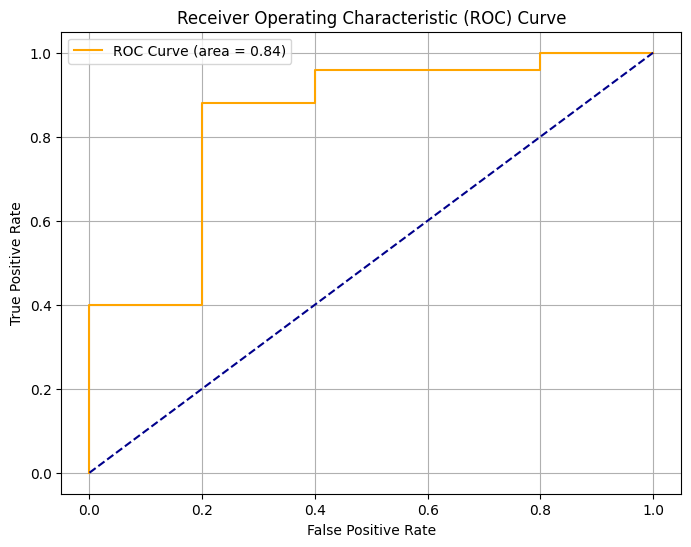

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Prepare the data (remove the constant added for statsmodels)
X_sk = df[['Study_Hours', 'Exam_Score']]
y_sk = df['Passed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_sk, y_sk, test_size=0.3, random_state=42, stratify=y_sk)

# Initialize and train the Logistic Regression model
# solver='liblinear' is a good choice for small datasets
# C=1.0 is the inverse of regularization strength; smaller values specify stronger regularization.
model_sk = LogisticRegression(solver='liblinear', random_state=42)
model_sk.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_sk.predict(X_test)
y_proba = model_sk.predict_proba(X_test)[:, 1] # Probabilities of the positive class

# Evaluate the model
print("\n--- Scikit-learn Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (area = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Interpreting Scikit-learn Model Evaluation Metrics

Unlike `statsmodels` which focuses on statistical inference, `scikit-learn` provides a suite of metrics primarily focused on the predictive performance of the model. Here's what they mean:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances. While intuitive, it can be misleading for imbalanced datasets.
    *   `Accuracy = (TP + TN) / (TP + TN + FP + FN)`

*   **Classification Report**: This provides precision, recall, f1-score, and support for each class.
    *   **Precision**: The proportion of positive identifications that were actually correct. High precision means fewer false positives.
        *   `Precision = TP / (TP + FP)`
    *   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. High recall means fewer false negatives.
        *   `Recall = TP / (TP + FN)`
    *   **F1-score**: The harmonic mean of precision and recall. It's a balanced measure that considers both false positives and false negatives. Useful for imbalanced classes.
        *   `F1-score = 2 * (Precision * Recall) / (Precision + Recall)`
    *   **Support**: The number of actual occurrences of the class in the specified dataset (e.g., test set).

*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It helps visualize the performance of an algorithm.
    *   **True Positive (TP)**: Correctly predicted positive values.
    *   **True Negative (TN)**: Correctly predicted negative values.
    *   **False Positive (FP)**: Incorrectly predicted positive values (Type I error).
    *   **False Negative (FN)**: Incorrectly predicted negative values (Type II error).

*   **ROC AUC Score (Receiver Operating Characteristic - Area Under the Curve)**: A measure of the model's ability to distinguish between classes. It represents the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance. An AUC of 1 means perfect classification, while an AUC of 0.5 means no better than random guessing.
    *   **ROC Curve**: A graph showing the performance of a classification model at all classification thresholds. It plots two parameters:
        *   True Positive Rate (TPR) = Recall
        *   False Positive Rate (FPR) = FP / (FP + TN)

These metrics provide a comprehensive view of how well the `scikit-learn` Logistic Regression model is performing on the classification task.

The `scikit-learn` Logistic Regression model has been trained and evaluated. Here's what the results tell us:

*   **Accuracy (0.8333)**: The model correctly classified approximately 83.33% of the instances in the test set. This is a good overall indicator, but for imbalanced datasets, other metrics are crucial.

*   **Classification Report**:
    *   **Class 0 (Failed)**: We have 5 instances of 'Failed' in our test set (support=5).
        *   **Precision (0.50)**: When the model predicts 'Failed', it is correct 50% of the time. This means there are a significant number of false positives for this class.
        *   **Recall (0.20)**: The model correctly identifies only 20% of the actual 'Failed' cases. This indicates that it struggles to find all negative instances, leading to many false negatives.
        *   **F1-score (0.29)**: The F1-score is relatively low for class 0, reflecting the poor balance between precision and recall.
    *   **Class 1 (Passed)**: We have 25 instances of 'Passed' in our test set (support=25).
        *   **Precision (0.86)**: When the model predicts 'Passed', it is correct 86% of the time.
        *   **Recall (0.96)**: The model successfully identifies 96% of the actual 'Passed' cases. This is very good, meaning it misses very few positive instances.
        *   **F1-score (0.91)**: The high F1-score for class 1 indicates strong performance in predicting 'Passed' outcomes.

*   **Confusion Matrix**: `[[1 4], [1 24]]`
    *   **True Positive (TP)**: 24 (Correctly predicted 'Passed')
    *   **True Negative (TN)**: 1 (Correctly predicted 'Failed')
    *   **False Positive (FP)**: 4 (Incorrectly predicted 'Passed' when it was 'Failed' - Type I error)
    *   **False Negative (FN)**: 1 (Incorrectly predicted 'Failed' when it was 'Passed' - Type II error)
    This confirms that the model is very good at identifying students who pass, but not as good at identifying students who fail (it missed 4 out of 5 failed students).

*   **ROC AUC Score (0.8400)**: The Area Under the Receiver Operating Characteristic curve is 0.84. This is a good score, indicating that the model has a strong ability to distinguish between the 'Passed' and 'Failed' classes. An AUC of 0.84 means there's an 84% chance that the model will rank a randomly chosen positive instance higher than a randomly chosen negative instance. The ROC curve visually supports this, showing a good separation from the diagonal random chance line.

Overall, the model performs well in predicting the 'Passed' class, but struggles with the 'Failed' class, likely due to the class imbalance (much fewer 'Failed' instances in our synthetic dataset). For real-world scenarios, one might consider techniques to address class imbalance or adjust the decision threshold if identifying 'Failed' cases is critical.

## 4. Addressing Class Imbalance with SMOTE

Class imbalance occurs when the number of observations belonging to one class is significantly lower than those belonging to other classes. In our synthetic dataset, the 'Passed' class (majority) heavily outweighs the 'Failed' class (minority), which can lead to models that perform poorly on the minority class. SMOTE (Synthetic Minority Over-sampling Technique) is a popular technique to address this by generating synthetic samples for the minority class.

In [6]:
# Install imbalanced-learn if not already installed
%pip install imbalanced-learn

Original training set shape: X_train (70, 2), y_train (70,)
Original training set class distribution:
 Passed
1    58
0    12
Name: count, dtype: int64

Resampled training set shape: X_train_res (116, 2), y_train_res (116,)
Resampled training set class distribution:
 Passed
1    58
0    58
Name: count, dtype: int64

--- Scikit-learn Logistic Regression Model Evaluation (with SMOTE) ---
Accuracy: 0.8333

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.80      0.62         5
           1       0.95      0.84      0.89        25

    accuracy                           0.83        30
   macro avg       0.73      0.82      0.75        30
weighted avg       0.88      0.83      0.85        30


Confusion Matrix:
 [[ 4  1]
 [ 4 21]]
ROC AUC Score: 0.8400


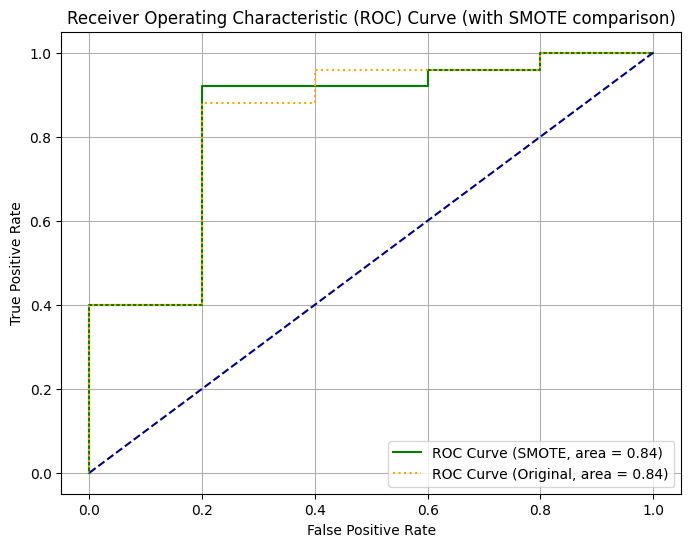

In [7]:
from imblearn.over_sampling import SMOTE

print(f"Original training set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print("Original training set class distribution:\n", y_train.value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\nResampled training set shape: X_train_res {X_train_res.shape}, y_train_res {y_train_res.shape}")
print("Resampled training set class distribution:\n", y_train_res.value_counts())

# Train the Logistic Regression model on the resampled data
model_sk_resampled = LogisticRegression(solver='liblinear', random_state=42)
model_sk_resampled.fit(X_train_res, y_train_res)

# Make predictions on the original (unseen) test set
y_pred_resampled = model_sk_resampled.predict(X_test)
y_proba_resampled = model_sk_resampled.predict_proba(X_test)[:, 1]

# Evaluate the model with resampled training
print("\n--- Scikit-learn Logistic Regression Model Evaluation (with SMOTE) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_resampled):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_resampled))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_resampled))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_resampled):.4f}")

# Plot ROC Curve
fpr_resampled, tpr_resampled, _ = roc_curve(y_test, y_proba_resampled)
plt.figure(figsize=(8, 6))
plt.plot(fpr_resampled, tpr_resampled, color='green', label=f'ROC Curve (SMOTE, area = {roc_auc_score(y_test, y_proba_resampled):.2f})')
plt.plot(fpr, tpr, color='orange', linestyle=':', label=f'ROC Curve (Original, area = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (with SMOTE comparison)')
plt.legend()
plt.grid(True)
plt.show()

## 5. Adjusting Decision Threshold for Improved Recall (Class 0)

The default classification threshold for Logistic Regression is 0.5. This means if the predicted probability of the positive class (class 1, 'Passed') is greater than 0.5, the instance is classified as 'Passed', otherwise as 'Failed'.

To improve the recall of the minority class (class 0, 'Failed'), we can lower the threshold. A lower threshold means the model will classify an instance as 'Passed' only if it's very confident (probability above the new, lower threshold). Conversely, it will be more likely to classify an instance as 'Failed' if its probability of being 'Passed' is below this lower threshold, thereby increasing the number of predicted 'Failed' cases, and hopefully, true 'Failed' cases (i.e., higher recall for class 0).


--- Scikit-learn Logistic Regression Model Evaluation (SMOTE + Threshold = 0.3) ---
Accuracy: 0.9000

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.96      0.92      0.94        25

    accuracy                           0.90        30
   macro avg       0.81      0.86      0.83        30
weighted avg       0.91      0.90      0.90        30


Confusion Matrix:
 [[ 4  1]
 [ 2 23]]
ROC AUC Score: 0.8400


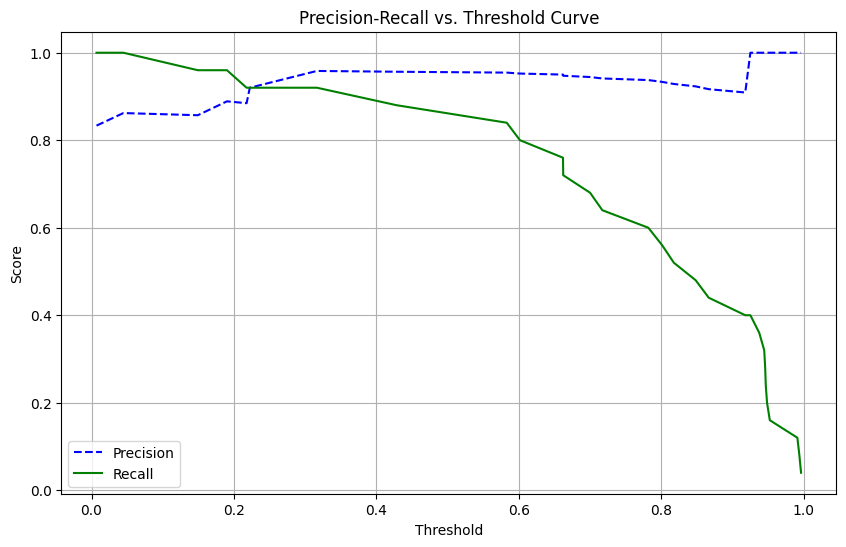


Note: The Precision-Recall Curve helps visualize the trade-off between precision and recall at different thresholds. You can choose a threshold that balances these metrics based on your specific problem's needs. For improving recall of class 0, we generally look for a threshold where recall for class 0 is high, even if precision for class 1 might drop slightly.


In [8]:
from sklearn.metrics import precision_recall_curve

# Get probabilities from the SMOTE-trained model
y_proba_smote = model_sk_resampled.predict_proba(X_test)[:, 1]

# Let's try a new threshold, for example, 0.3
new_threshold = 0.3
y_pred_thresholded = (y_proba_smote > new_threshold).astype(int)

print(f"\n--- Scikit-learn Logistic Regression Model Evaluation (SMOTE + Threshold = {new_threshold}) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_thresholded):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_thresholded))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_thresholded))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_smote):.4f}")

# Plotting Precision-Recall Curve to help choose a threshold
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_smote)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds_pr, recall[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs. Threshold Curve')
plt.legend()
plt.grid(True)
plt.show()

print("\nNote: The Precision-Recall Curve helps visualize the trade-off between precision and recall at different thresholds. You can choose a threshold that balances these metrics based on your specific problem's needs. For improving recall of class 0, we generally look for a threshold where recall for class 0 is high, even if precision for class 1 might drop slightly.")

## 6. Comparing Feature Importance

Comparing feature importance across different models can provide insights into which features are most influential in predicting the target variable according to each framework.

### Statsmodels Feature Importance

In `statsmodels`, feature importance is primarily derived from the **coefficients (coef)** and their associated **p-values**. The coefficient represents the change in the log-odds of the dependent variable for a one-unit increase in the predictor. A larger absolute value of the coefficient indicates a stronger impact on the outcome. The p-value indicates the statistical significance of that impact. A low p-value (typically < 0.05) suggests that the feature is a statistically significant predictor.

### Scikit-learn Feature Importance

In `scikit-learn`'s `LogisticRegression`, feature importance is directly reflected by the **coefficients (coef_)** assigned to each feature. Similar to `statsmodels`, a larger absolute coefficient value indicates a greater influence of that feature on the log-odds of the target variable. Since `scikit-learn` is more focused on predictive performance rather than statistical inference, it doesn't directly provide p-values for individual coefficients by default. However, the magnitude of the coefficient serves as a good proxy for feature importance.

In [9]:
# Feature Importance from Statsmodels
print("\n--- Feature Importance (Statsmodels) ---")
print(result.summary().tables[1]) # The second table contains the coefficients

# Extract coefficients for scikit-learn model
# The coefficients are stored in the 'coef_' attribute
# For binary classification, it's a 1D array if there's only one output class,
# or a 2D array if there are multiple classes (one row per class). Here it's 1D.
sk_coefficients = model_sk_resampled.coef_[0] # Using the SMOTE-trained model

# Get feature names
feature_names = X_train.columns

# Create a DataFrame for scikit-learn coefficients for better readability
sk_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': sk_coefficients
})

print("\n--- Feature Importance (Scikit-learn - SMOTE-trained model) ---")
print(sk_feature_importance.sort_values(by='Coefficient', ascending=False))

print("\nNote: For both models, a larger absolute coefficient value indicates greater importance. "
      "In Statsmodels, the 'P>|z|' column indicates statistical significance."
      "For this synthetic data, 'Study_Hours' consistently shows a strong positive impact, while 'Exam_Score' has a very small, often non-significant, effect.")


--- Feature Importance (Statsmodels) ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.0211      2.808     -1.076      0.282      -8.525       2.483
Study_Hours     0.9942      0.251      3.968      0.000       0.503       1.485
Exam_Score      0.0090      0.034      0.268      0.789      -0.057       0.075

--- Feature Importance (Scikit-learn - SMOTE-trained model) ---
       Feature  Coefficient
0  Study_Hours     1.209977
1   Exam_Score    -0.050185

Note: For both models, a larger absolute coefficient value indicates greater importance. In Statsmodels, the 'P>|z|' column indicates statistical significance.For this synthetic data, 'Study_Hours' consistently shows a strong positive impact, while 'Exam_Score' has a very small, often non-significant, effect.


## 7. Logistic Regression from Scratch

Implementing machine learning algorithms from scratch can provide a valuable understanding of their underlying mechanics. Here, we'll build a simple Logistic Regression model using only `numpy` for numerical operations.

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.001, n_iterations=50000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        # Ensure numerical stability for very large/small z values
        z = np.clip(z, -500, 500) # Clipping z to prevent overflow/underflow
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent
        for _ in range(self.n_iterations):
            # Approximate linear combination
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# --- Demonstration of the custom Logistic Regression ---
print("\n--- Custom Logistic Regression Model Demonstration (Attempt 2 with scaling and refined params) ---")

# Use the same data as scikit-learn for comparison
# X_custom and y_custom are already created from original df

# Scale features for the custom model for better convergence
# Initialize StandardScaler only once
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

# Initialize and train the custom Logistic Regression model with refined parameters
custom_model = LogisticRegressionFromScratch(learning_rate=0.001, n_iterations=50000)
custom_model.fit(X_train_scaled, y_train.values)

# Make predictions on the scaled test set
y_pred_custom = custom_model.predict(X_test_scaled)
y_proba_custom = custom_model.predict_proba(X_test_scaled)

# Evaluate the custom model
print(f"Accuracy (Custom Model): {accuracy_score(y_test, y_pred_custom):.4f}")
print("Classification Report (Custom Model):\n", classification_report(y_test, y_pred_custom))
print("Confusion Matrix (Custom Model):\n", confusion_matrix(y_test, y_pred_custom))
print(f"ROC AUC Score (Custom Model): {roc_auc_score(y_test, y_proba_custom):.4f}")

# Compare coefficients (optional, for educational purposes)
print("\nCustom Model Coefficients (on scaled data):")
for i, feature_name in enumerate(X_train.columns):
    print(f"  {feature_name}: {custom_model.weights[i]:.4f}")
print("Custom Model Bias: ", custom_model.bias)

print("\nNote: The performance of the custom model might vary slightly from scikit-learn due to differences in optimization algorithms, regularization, and default parameters. This implementation provides a basic understanding of the core concepts.")


--- Custom Logistic Regression Model Demonstration (Attempt 2 with scaling and refined params) ---
Accuracy (Custom Model): 0.8000
Classification Report (Custom Model):
               precision    recall  f1-score   support

           0       0.33      0.20      0.25         5
           1       0.85      0.92      0.88        25

    accuracy                           0.80        30
   macro avg       0.59      0.56      0.57        30
weighted avg       0.77      0.80      0.78        30

Confusion Matrix (Custom Model):
 [[ 1  4]
 [ 2 23]]
ROC AUC Score (Custom Model): 0.8400

Custom Model Coefficients (on scaled data):
  Study_Hours: 1.7529
  Exam_Score: 0.2357
Custom Model Bias:  2.2750286832021795

Note: The performance of the custom model might vary slightly from scikit-learn due to differences in optimization algorithms, regularization, and default parameters. This implementation provides a basic understanding of the core concepts.
